# Terminus-2 over NL2RepoBench: what the loop scored, and what it consumed

Job `2026-09-05__02-26-02` is 104 trials — every task in the benchmark, once each, one
model, and an agent loop with a shell rather than a single request. Where the
single-shot baseline had to emit a whole repository in one reply, this one can run
commands, read what came back, and decide what to do next, up to a budget of 58 turns.
The interesting question is not only what that buys, but what it consumes, and which of the
two ceilings — output tokens there, turns here — actually binds.

This notebook reads the job directory as it stands on disk and asks:

1. **What did it score?** — the reward distribution, and how it moves with difficulty.
2. **How much of the loop was used?** — turns spent per trial, how often the budget ran
   out, and whether running out costs anything.
3. **What did the tokens buy?** — tokens per trial against reward earned, and why an
   arm that reads 300 million input tokens is not the most expensive one.
4. **How did the zeros happen?** — a zero from failing tests and a zero from an
   unimportable package are different findings, and the verifier logs tell them apart.

Nothing here is re-run or re-scored; every number is read from the files the job wrote.
This is one of three run notebooks that share a reader and a set of figures, and it
makes **no comparison between the arms** — that is a separate exercise once every arm
has been run.

## 1. Parameters

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# --- what to read ------------------------------------------------------------
JOB = "2026-09-05__02-26-02"

# Reward at or above which a task counts as solved rather than partially credited.
# Not 1.0: a run that passes 95% of a package's hidden tests has produced a working
# package, and calling that a failure would flatter every method equally. Every
# other threshold this notebook uses is a budget, and those are read from each
# trial's own configuration rather than restated here.
SOLVED_AT = 0.9

# Figures are prefixed so the arms' figures sit beside each other in docs/figures
# without overwriting one another.
FIGURE_PREFIX = "terminus"

# `job_analysis` and `job_figures` live beside the notebooks. Jupyter puts the
# notebook's own directory on the path; this covers a kernel started elsewhere.
NOTEBOOKS = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS))

import matplotlib.pyplot as plt

import job_analysis as ja
import job_figures as jf

jf.use_house_style()
save = jf.saver(FIGURE_PREFIX)

df = ja.load_job(JOB, solved_at=SOLVED_AT)
print(f"job     : {ja.job_path(JOB)}")
print(f"arm     : {df.attrs['arm'].name}")
print(f"budget  : {df.attrs['arm'].budget_name} = {df.attrs['budget']}")
print(f"solved  : reward >= {SOLVED_AT}")
print()
print(ja.headline(df))
print()
print(df.outcome.value_counts().to_string())

job     : C:\Code\EvaluationPlatform\jobs\2026-09-05__02-26-02
arm     : terminus-2
budget  : max_turns = 58
solved  : reward >= 0.9

trials          : 104  (100 scored, 4 lost to a host fault)
mean reward     : 0.321   median 0.281   (n=100)
total tokens    : 307.7M  (95% of input served from cache)
total wall clock: 15.6 h summed over trials

outcome
partial credit        64
never imported        13
no verdict             8
solved                 8
lost to host fault     4
ran, all failed        4
never configured       3


## 2. Conventions

Two rules govern every figure, and both live in `job_figures` rather than being
restated per notebook.

**Ordered variables get ordered ramps.** Difficulty, token quartile and failure stage
are all ordered, so each gets one hue running light to dark rather than a set of
arbitrary colours. Where none of them is the subject, grey is context and blue is the
thing being shown; red is reserved for the one thing a figure is warning about.

**Text on a figure is a title, an axis word, and direct labels on the marks.** The
strings for the shared figures are in `jf.FIGURE_TEXT` and every one of them takes a
`text=` override, so re-wording a chart never means touching plotting code. Titles that
quote a number are format strings filled from the data at draw time, so they cannot go
stale when `JOB` changes. The cell below holds the same thing for the figures that only
this notebook draws.

In [2]:
import matplotlib.pyplot as plt

# The figures only this notebook draws. Everything else is `jf.FIGURE_TEXT`.
TEXT = {
    "turns": dict(
        title="{n_cut} Läufe nutzen das ganze Turn-Budget",
        x="genutzte Turns", y="Reward", note="Budget",
    ),
    "ceiling": dict(
        title="Turns auszugehen kostet auf Schwer am meisten",
        x="", y="mittlerer Reward",
        series={"declared complete": "als fertig gemeldet",
                "cut at turn ceiling": "am Budget abgeschnitten"},
    ),
}

## 3. Reading the job directory

`ja.load_job` returns one row per trial. Its shared half — reward, tokens,
timings, the pytest summary, and the reason behind every flat zero — is read the same
way for every arm, so a cause counted here means what it means in the other run
notebooks. `ja.COMMON_COLUMNS` is that contract; anything else on the frame is this
arm's own, listed in its `ja.ARMS` entry.

What this arm records on top comes from the loop: `episodes` (turns used),
`summarizations`, `median_request_ms`, and `final_call` — the last tool the agent
invoked, which is what distinguishes a loop that declared itself finished from one that
was stopped mid-command. The budget here is `max_turns`.

Two things about this job need saying before any number is read from it.

**Four trials have no reward at all.** They failed on the *host*, after the agent had
finished, with `[WinError 206] The filename or extension is too long` — a Windows
command-line limit hit while collecting artifacts, so the verifier never ran. Those
trials are not zeros; they are missing, and `ja.load_job` carries them as `NaN` with
`scored = False` rather than as `0`, so they cannot quietly drag a mean down. Every
aggregate below states the number of trials it is over.

**`trajectory.json` contains the API key** the run was launched with, in
`agent.extra.llm_kwargs`. `jobs/` is in `.gitignore`, so it is not committed — but it is
sitting in plaintext on disk, and a job directory should not be attached to an issue or
shared as-is without stripping it. Nothing here reads that field: the reader takes the
final tool name with a targeted pattern rather than parsing the document.

## 4. What the run scored

Ranking every trial rather than binning them shows the shape of the distribution
without a choice of bin width doing any of the arguing. The four trials that never
reached the verifier are not on this figure at all — they have no reward to rank.

wrote docs\figures\terminus-reward-ranked.png


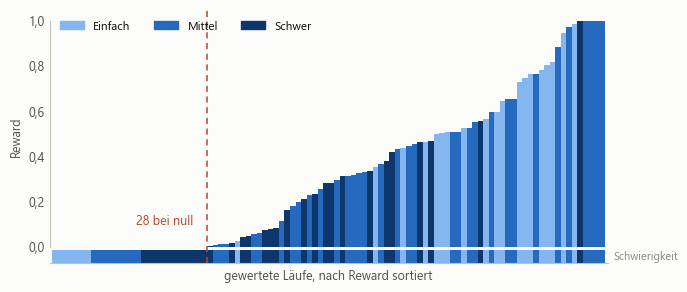

            trials at zero  scored trials  share of the level
difficulty                                                   
Easy                     7             26                0.27
Medium                   9             42                0.21
Hard                    12             32                0.38


In [3]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_ranked(df), "reward-ranked")
plt.show()

print(ja.zero_rate(df).round(2).to_string())

Difficulty is the benchmark's own label, assigned from lines of code before any model
saw the task, so the gradient below is less a finding about this run than a check that
the run behaves the way the label says it should.

wrote docs\figures\terminus-reward-by-difficulty.png


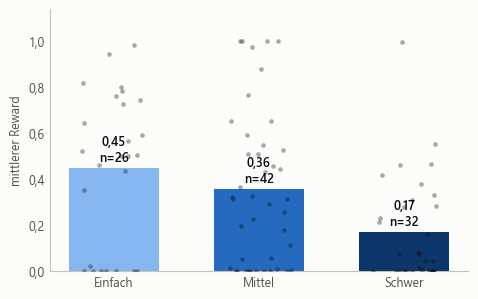

In [4]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_by_difficulty(df), "reward-by-difficulty")
plt.show()

## 5. The turn budget

The loop's ceiling is not a token count but a turn count: 58 shell round-trips, after
which it is stopped wherever it happens to be. A trial that used all 58 and whose last
act was still a `bash_command` was cut off mid-work; one that called
`mark_task_complete` decided for itself that it was done — including a single trial that
did so on its very last allowed turn, which is a finished run rather than a truncated
one and is counted as such.

Plotting turns against reward puts the whole question on one figure: how much of the
budget gets used, how many trials pile up against it, and what those trials scored.

wrote docs\figures\terminus-turns-versus-reward.png


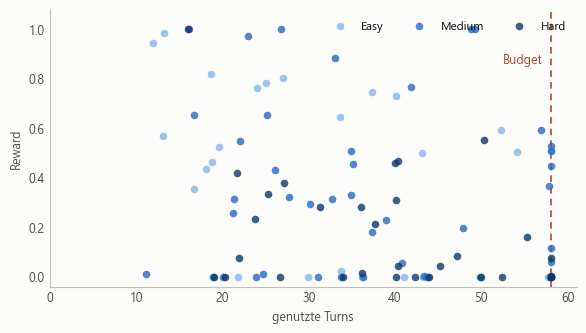

turns used    : median 35, mean 34.9, of a 58-turn budget
at the budget : 13 of 104 trials
summarizations: 0 over the whole run — the context window was never exhausted


In [5]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["turns"]
ceiling = df.budget_value.iloc[0]
scored = df[df.scored]
rng = np.random.default_rng(0)   # horizontal jitter only, turns are integers

fig, ax = plt.subplots(figsize=(6.8, 3.6))
for level in ja.LEVELS:
    part = scored[scored.difficulty == level]
    # Jitter separates the trials stacked on one turn count, but never carries a
    # point past the budget it did not exceed.
    jittered = (part.episodes + rng.uniform(-0.35, 0.35, len(part))).clip(upper=ceiling)
    ax.scatter(
        jittered, part.reward, s=30, label=level,
        color=jf.BAND_COLOR[level], alpha=0.8, linewidth=0, zorder=3,
    )
ax.axvline(ceiling, color=jf.ALERT, linestyle=(0, (4, 3)), linewidth=1.2, zorder=2)
ax.annotate(
    t["note"], xy=(ceiling, 0.86), xytext=(-6, 0), textcoords="offset points",
    color=jf.ALERT, ha="right", fontsize=9,
)

jf.title(ax, t["title"], n_cut=int(df.hit_budget.sum()))
ax.set_xlabel(t["x"])
ax.set_ylabel(t["y"])
ax.set_ylim(-0.04, 1.08)
ax.set_xlim(0, ceiling + 3)
ax.legend(loc="upper right", ncol=3)
jf.tidy(ax)
save(fig, "turns-versus-reward")
plt.show()

print(f"turns used    : median {df.episodes.median():.0f}, mean {df.episodes.mean():.1f},"
      f" of a {ceiling}-turn budget")
print(f"at the budget : {int(df.hit_budget.sum())} of {len(df)} trials")
print(f"summarizations: {int(df.summarizations.sum())} over the whole run"
      f" — the context window was never exhausted")

Splitting reward by how the loop ended asks whether the budget actually costs anything.
It does, and mostly on Hard — but the cells here are small, two to seven trials each,
so the counts are printed on every bar. This is a direction, not a measurement.

wrote docs\figures\terminus-ceiling-effect.png


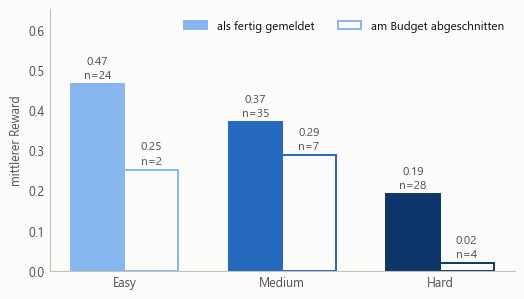

In [6]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["ceiling"]

ENDINGS = ["declared complete", "cut at turn ceiling"]
scored = df[df.scored]
mean = scored.pivot_table(index="difficulty", columns="ending", values="reward",
                          aggfunc="mean", observed=True).reindex(ja.LEVELS)
count = scored.pivot_table(index="difficulty", columns="ending", values="reward",
                           aggfunc="size", observed=True).reindex(ja.LEVELS)
x = np.arange(len(ja.LEVELS))
width = 0.34

fig, ax = plt.subplots(figsize=(6.0, 3.4))
for offset, ending in ((-width / 2, ENDINGS[0]), (width / 2, ENDINGS[1])):
    values = mean.get(ending)
    cut = ending == ENDINGS[1]
    # Solid = the loop finished; hollow = it was stopped. Fill treatment rather
    # than a second colour, so the difficulty ramp keeps its one meaning.
    bars = ax.bar(
        x + offset, values, width, label=t["series"][ending],
        color=[jf.SURFACE if cut else jf.BAND_COLOR[d] for d in ja.LEVELS],
        edgecolor=[jf.BAND_COLOR[d] for d in ja.LEVELS], linewidth=1.4, zorder=2,
    )
    for rect, value, n in zip(bars, values, count.get(ending)):
        ax.annotate(
            f"{value:.2f}\nn={int(n)}",
            xy=(rect.get_x() + rect.get_width() / 2, value), xytext=(0, 4),
            textcoords="offset points", ha="center", fontsize=8.5,
            color=jf.INK_2, linespacing=1.3,
        )

jf.title(ax, t["title"])
ax.set_ylabel(t["y"])
ax.set_ylim(0, np.nanmax(mean.to_numpy()) * 1.4)
ax.set_xticks(x)
ax.set_xticklabels(ja.LEVELS)
ax.legend(loc="upper right", ncol=2)
jf.tidy(ax)
save(fig, "ceiling-effect")
plt.show()

## 6. What the tokens bought

Three hundred million input tokens for four dollars is not a typo. The loop resends its
whole transcript every turn, so input grows with the square of the conversation — and
almost all of it is served from the prompt cache, at a fraction of the price. The cache
is what makes this shape of agent affordable at all; the figures printed below the next
chart give the share.

wrote docs\figures\terminus-token-quartiles.png


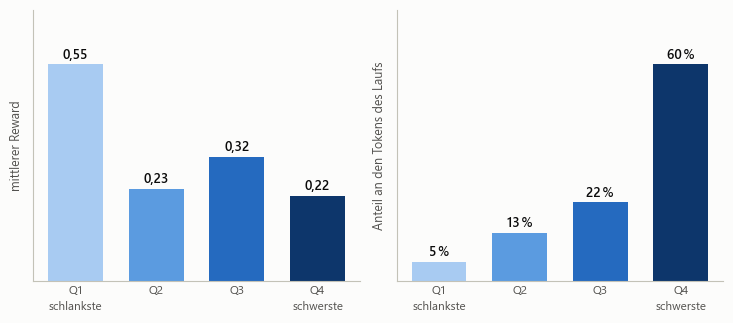

              mean_reward     tokens   n  share
quartile                                       
Q1\nleanest         0.552   16067779  26  0.052
Q2                  0.235   40503271  26  0.132
Q3                  0.316   66603062  26  0.216
Q4\nheaviest        0.217  184511258  26  0.600

            trials  median_tok  mean_reward
difficulty                                 
Easy            26   1328245.5       0.4493
Medium          46   1807757.0       0.3572
Hard            32   3596841.5       0.1698

Hard against Easy: median tokens x2.7, mean reward x0.38

the prompt cache, over the whole run
  input tokens  : 303.7M
  served cached : 287.7M  (94.7%)
  output tokens : 3.99M
  median input per turn: 54,506 tokens


In [7]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.token_quartiles(df), "token-quartiles")
plt.show()

print(ja.token_quartile_table(df).round(3).to_string())
print()

levels = ja.by_difficulty(df)
print(levels.round(4).to_string())
print()
# Stated as a ratio in a fixed direction rather than as "more" or "less": not
# every arm consumes more on the harder half, and one of them consumes less.
tok = levels.median_tok["Hard"] / levels.median_tok["Easy"]
reward = levels.mean_reward["Hard"] / levels.mean_reward["Easy"]
print(f"Hard against Easy: median tokens x{tok:.1f}, mean reward x{reward:.2f}")

print()
print("the prompt cache, over the whole run")
print(f"  input tokens  : {df.in_tok.sum() / 1e6:.1f}M")
print(f"  served cached : {df.cache_tok.sum() / 1e6:.1f}M"
      f"  ({df.cache_tok.sum() / df.in_tok.sum():.1%})")
print(f"  output tokens : {df.out_tok.sum() / 1e6:.2f}M")
print(f"  median input per turn: {(df.in_tok / df.episodes).median():,.0f} tokens")

Aggregating the same consumption by what it produced gives the figure worth quoting.

wrote docs\figures\terminus-tokens-by-outcome.png


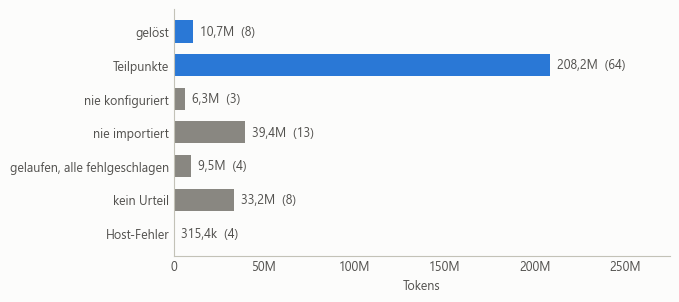

In [8]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.tokens_by_outcome(df), "tokens-by-outcome")
plt.show()

## 7. Why each zero was a zero

"Scored nothing" is not a diagnosis. The verifier writes a full pytest report for every
trial, and that report names the exception that stopped the run — so each zero can be
given the technical reason it earned, read from its own output rather than assigned by
hand. `ja.classify_zero` does this identically for every arm.

Each zero gets a **stage** and a **cause**. The stage is how far the pipeline got:

| Stage | Meaning |
| --- | --- |
| `never configured` | pytest refused to start — unparsable `pyproject.toml`, a config option needing a plugin that is not installed, an incompatible plugin, or no tests collected at all |
| `never imported` | pytest started, and the generated code failed to import |
| `ran, all failed` | the code imported, the tests executed, and every one of them failed |
| `no verdict` | the tester never produced a real judgement — a harness fault, not a finding about the code |

The cause is the exception itself. Two of them are refined further, because the
exception name on its own hides the mistake:

- **`ModuleNotFoundError`** is four different errors. *Own code, wrong layout* — the
  file is in the workspace, but not importable under the name its own code uses.
  *A file it never wrote* — the package is there, the module it imports is not.
  *Uninstalled dependency* — a third-party library the agent assumed would be present.
  *Project built one level too deep* — the whole project sits inside a single
  sub-directory of the workspace. Which one is decided by looking the missing name up
  against everything the agent actually wrote, as a dotted path resolved against both
  import roots and, failing that, against a nested project root.
- **`ImportError`** is three more: a *circular import*; a name *missing from its own
  module*; and a name *gone from an installed module*, which means the code was written
  against an API the installed version does not have.

Where one report holds several exceptions, the cause is the one raised most often — the
error blocking most of the suite, not whichever pytest printed first.

The first `ModuleNotFoundError` category is the single largest cause of a zero in this
run, and it is worth dwelling on: the loop has a shell, and it used it to `mkdir` a
project directory and build inside it. One of them created `/workspace/workspace/`.
These are not wrong answers — they are correct repositories at the wrong path, one `mv`
from scoring.

wrote docs\figures\terminus-zero-causes.png


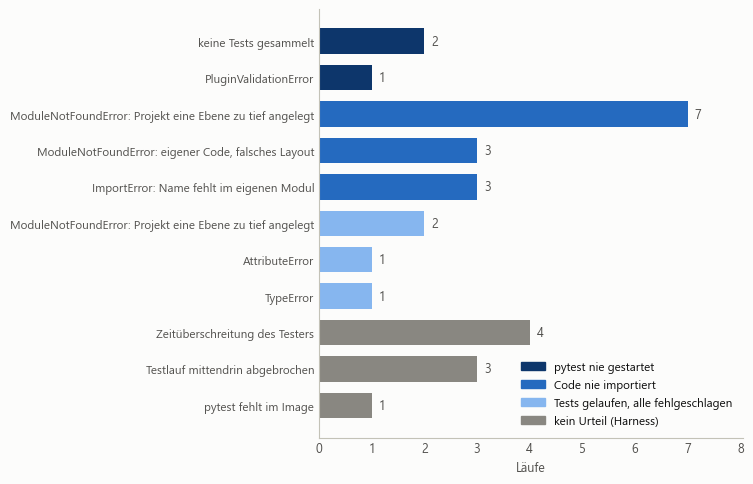

fault_stage
never configured     3
never imported      13
ran, all failed      4
no verdict           8


In [9]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.zero_causes(df), "zero-causes")
plt.show()

zeros = df[df.scored & (df.reward == 0)]
print(zeros.fault_stage.value_counts().reindex(ja.STAGES).fillna(0).astype(int).to_string())

The task behind each row is worth having to hand when reading the figure, so the full
list is printed below, together with the four trials that never reached a verifier at
all.

In [10]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)
zeros = df[df.scored & (df.reward == 0)]

table = (zeros[["task", "difficulty", "fault_stage", "fault_cause", "ending", "episodes"]]
         .sort_values(["fault_stage", "fault_cause", "task"])
         .reset_index(drop=True))
with pd.option_context("display.max_rows", None, "display.width", 210,
                       "display.max_colwidth", 44):
    print(table.to_string())

print()
print("trials with no reward at all (host fault, excluded from every mean above)")
print(df[~df.scored][["task", "difficulty", "episodes", "total_tok", "exception"]]
      .to_string(index=False))

                    task difficulty       fault_stage                                            fault_cause               ending  episodes
0                 tinydb     Medium  never configured                                  PluginValidationError    declared complete        50
1                   tqdm       Hard  never configured                                no tests were collected    declared complete        27
2             voluptuous     Medium  never configured                                no tests were collected    declared complete        36
3             markupsafe       Easy    never imported          ImportError: name missing from its own module  cut at turn ceiling        58
4         python-slugify       Easy    never imported          ImportError: name missing from its own module    declared complete        22
5              verifiers       Hard    never imported          ImportError: name missing from its own module    declared complete        20
6     graphneuralnet

## 8. Two checks on the numbers above

**The reward is what it claims to be.** Reward arrives as a single float in
`result.json`, computed inside the container by a tester this notebook never sees. It
should be the fraction of hidden tests that passed, and pytest's own summary line —
parsed independently, out of a different file — agrees with it closely. The residual
gap is that pytest counts a collection error as one unit where the tester counts the
tests it would have contained.

**Every zero was classified, and none was left over.** A zero the classifier could not
read would be filed as `unclassified`, and the count of those is printed below, so that
a silent gap in the taxonomy cannot pass as a clean result.

In [11]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)

ran = df[df.scored & df.pt_ran].copy()
units = (ran.pt_passed + ran.pt_failed + ran.pt_error).replace(0, pd.NA)
ran["pytest_fraction"] = ran.pt_passed / units
agree = ran.dropna(subset=["pytest_fraction"])

print("reward against pytest's own pass fraction")
print(f"  trials compared : {len(agree)} of {int(df.scored.sum())} scored"
      f" ({int(df.scored.sum()) - len(ran)} excluded, pytest never reached a summary)")
print(f"  correlation     : r = {agree.reward.corr(agree.pytest_fraction):.3f}")
print(f"  median gap      : {(agree.reward - agree.pytest_fraction).abs().median():.3f}")
print()

zeros = df[df.scored & (df.reward == 0)]
print(f"unclassified zeros: {int((zeros.fault_cause == 'unclassified').sum())} of {len(zeros)}")
print()
print("how the run stopped, and what each way scored")
print(df.groupby("ending").agg(
    trials=("reward", "size"), mean_reward=("reward", "mean"),
    zeros=("reward", lambda s: int((s == 0).sum()))).round(3).to_string())

reward against pytest's own pass fraction
  trials compared : 74 of 100 scored (25 excluded, pytest never reached a summary)
  correlation     : r = 0.981
  median gap      : 0.000

unclassified zeros: 0 of 28

how the run stopped, and what each way scored
                     trials  mean_reward  zeros
ending                                         
cut at turn ceiling      13        0.200      4
declared complete        87        0.339     24
lost to host fault        4          NaN      0


## What this run says

- **The median trial scores something.** Mean reward 0.32 over the 100 scored trials,
  median 0.28, with a substantial partial-credit body rather than a spike at zero. Four
  tasks are reproduced outright.
- **Difficulty still dominates.** Easy to Hard is a steep drop in reward and a rise in
  both tokens and turns used, in the same direction — so a comparison run on a
  difficulty-skewed subset will read very differently from one run on the full
  benchmark. That is the case for the balanced subset selected in
  `nl2repobench-subset-selection.ipynb`.
- **The turn budget binds, but rarely.** Thirteen of 104 trials were stopped mid-work at
  58 turns; the median trial used about 35 and stopped because it decided it was
  finished. Raising the budget would move a small, mostly-Hard group. Context
  summarization never triggered once, so the transcript never came close to filling the
  window.
- **The prompt cache is doing the work.** 304M input tokens across the run against 4.0M
  written, and 95% of that input served from cache. An agent loop of this shape is only
  affordable because the transcript it resends every turn is nearly free the second time
  — which is also why counting its total tokens and counting what it generated give very
  different answers about how lean it is.
- **The commonest single cause of a zero is a directory mistake.** Nine trials built the
  whole project one level below `/workspace`, where nothing can import it. That is a
  property of giving the agent a shell, it is invisible in the reward alone, and it is
  the easiest thing on this list to fix — a line in the prompt about where the project
  root is, or a check before the verifier runs.
- **Four trials were lost to the host, not the model.** A Windows command-line length
  limit killed artifact collection after the agent had finished. They are excluded from
  every mean here; re-running them on a shorter path would recover four real data
  points.